## Clasificación con un dataset real: Iris

Después de trabajar problemas de **regresión**, ahora abordamos un problema de
**clasificación**, donde la variable objetivo **no es numérica**, sino una
**categoría o clase**.

Para este ejemplo utilizaremos el **dataset Iris**, uno de los conjuntos de datos
más utilizados en introducción a Machine Learning.

Este dataset contiene mediciones de flores del género *Iris* y el objetivo es
**clasificar cada observación en una de tres especies** diferentes.

¿Por qué usar Iris?
- Es pequeño y fácil de entender.
- Tiene pocas variables de entrada.
- Permite enfocarse en el concepto de clasificación sin complejidad adicional.


In [1]:
from sklearn.datasets import load_iris

# Cargamos el dataset Iris
data = load_iris()

X = data.data      # Variables de entrada
y = data.target    # Etiquetas de clase

print("Forma de X:", X.shape)
print("Forma de y:", y.shape)


Forma de X: (150, 4)
Forma de y: (150,)


## Variables de entrada y clases del dataset

En un problema de clasificación es importante identificar:
- las **variables de entrada** (features),
- y las **clases** que el modelo debe predecir.

En el dataset Iris:
- Las variables de entrada son medidas físicas de las flores.
- La variable objetivo indica la **especie** a la que pertenece cada flor.

A continuación veremos los nombres de las variables y las clases disponibles.


In [2]:
import pandas as pd

# Nombres de las variables de entrada
print("Variables de entrada:", data.feature_names)

# Nombres de las clases
print("Clases:", data.target_names)

# Visualizamos algunas filas del dataset
df = pd.DataFrame(X, columns=data.feature_names)
df["clase"] = y
df[df["clase"]==1].head(20)


Variables de entrada: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Clases: ['setosa' 'versicolor' 'virginica']


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),clase
50,7.0,3.2,4.7,1.4,1
51,6.4,3.2,4.5,1.5,1
52,6.9,3.1,4.9,1.5,1
53,5.5,2.3,4.0,1.3,1
54,6.5,2.8,4.6,1.5,1
55,5.7,2.8,4.5,1.3,1
56,6.3,3.3,4.7,1.6,1
57,4.9,2.4,3.3,1.0,1
58,6.6,2.9,4.6,1.3,1
59,5.2,2.7,3.9,1.4,1


## Exploración visual de los datos (clasificación)

Antes de entrenar un modelo de clasificación, es útil **visualizar los datos**
para observar cómo se distribuyen las distintas clases.

En el dataset Iris, aunque existen cuatro variables de entrada, podemos
seleccionar **dos variables** para construir una gráfica en 2D.
Esto nos permite ver:
- si las clases parecen separables,
- cómo se agrupan los datos,
- y por qué la clasificación


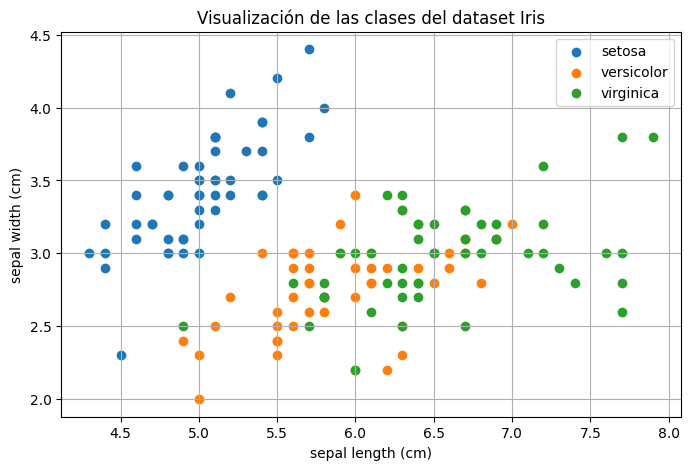

In [3]:
import matplotlib.pyplot as plt

# Seleccionamos dos variables para la visualización
x_index = 0  # sepal length
y_index = 1  # sepal width

plt.figure(figsize=(8, 5))

for class_value in range(len(data.target_names)):
    plt.scatter(
        X[y == class_value, x_index],
        X[y == class_value, y_index],
        label=data.target_names[class_value]
    )

plt.xlabel(data.feature_names[x_index])
plt.ylabel(data.feature_names[y_index])
plt.title("Visualización de las clases del dataset Iris")
plt.legend()
plt.grid(True)
plt.show()


## División de los datos: entrenamiento y prueba

Una vez que hemos observado visualmente la distribución de las clases,
procedemos a dividir el dataset en dos subconjuntos:

- **Entrenamiento**: datos usados por el modelo para aprender los patrones.
- **Prueba**: datos no vistos durante el entrenamiento, que simulan nuevos casos.

Esta división es fundamental para evaluar, a nivel conceptual, si el modelo
puede **generalizar** y asignar correctamente una clase a nuevas observaciones.


In [4]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42
)

print("Datos de entrenamiento:", X_train.shape)
print("Datos de prueba:", X_test.shape)


Datos de entrenamiento: (112, 4)
Datos de prueba: (38, 4)


## Entrenamiento de un modelo de clasificación

Ahora entrenaremos un modelo que sea capaz de **asignar una clase** a nuevas
observaciones, a partir de las variables de entrada.

Para iniciar con algo simple y muy usado en cursos introductorios, utilizaremos
**k-Nearest Neighbors (k-NN)**.

Idea general de k-NN:
- Para clasificar un nuevo dato, el modelo busca los **k vecinos más cercanos**
  en el conjunto de entrenamiento.
- La clase predicha será la **clase más común** entre esos vecinos.

En esta primera aproximación, no ajustaremos aún métricas ni optimización;
solo entrenaremos el modelo y lo usaremos para predecir.


In [5]:
from sklearn.neighbors import KNeighborsClassifier

# Creamos el clasificador k-NN (k=5 es un valor común para iniciar)
knn = KNeighborsClassifier(n_neighbors=5)

# Entrenamos el modelo
knn.fit(X_train, y_train)


KNeighborsClassifier()

## Predicción de clases con el modelo entrenado

Una vez entrenado el clasificador, podemos usarlo para **predecir la clase**
de datos que el modelo no vio durante el entrenamiento (conjunto de prueba).

En clasificación, la salida del modelo es una **etiqueta de clase**.
A continuación realizaremos predicciones y compararemos algunas de ellas
con la clase real para observar el comportamiento del modelo.


In [6]:
# Predicciones sobre el conjunto de prueba
y_pred = knn.predict(X_test)

# Comparamos algunas predicciones con los valores reales
for real, pred in zip(y_test[:10], y_pred[:10]):
    print(f"Clase real: {data.target_names[real]} | Clase predicha: {data.target_names[pred]}")


Clase real: versicolor | Clase predicha: versicolor
Clase real: setosa | Clase predicha: setosa
Clase real: virginica | Clase predicha: virginica
Clase real: versicolor | Clase predicha: versicolor
Clase real: versicolor | Clase predicha: versicolor
Clase real: setosa | Clase predicha: setosa
Clase real: versicolor | Clase predicha: versicolor
Clase real: virginica | Clase predicha: virginica
Clase real: versicolor | Clase predicha: versicolor
Clase real: versicolor | Clase predicha: versicolor
